# Surrogate data and nonlinearity testing

This notebook demonstrates the `nolitisea.surrogates` module.  Surrogate
testing decides whether a time series contains *nonlinear deterministic
structure* beyond what a linear stochastic process can explain: generate an
ensemble of surrogate series that mimic the linear properties (spectrum and
distribution) of the data, compute a discriminating statistic on the data
and on every surrogate, and check whether the data value is extreme within
the surrogate distribution.

| # | Routine | Purpose | Returns |
|---|---------|---------|---------|
| 1 | `endtoend.endtoend` | pick the sub-sequence with the smoothest wrap-around | optimal `(length, offset)` and mismatch values |
| 2 | `surrogates.ft` | Fourier-transform (phase-randomised) surrogates | surrogate series |
| 3 | `surrogates.aaft` / `surrogates.iaaft` | amplitude-adjusted surrogates | surrogate series (+ IAAFT convergence info) |
| 4 | `statistics.time_reversibility` | time-reversal asymmetry discriminant | T statistic |
| 5 | `statistics.predict_stat` | local prediction-error discriminant | RMSE |

The running example contrasts a **nonlinear deterministic** series (chaotic
logistic map) with a **linear stochastic** one (Gaussian AR(1) process,
which satisfies the surrogate null hypothesis).  A correct test must reject
the first and retain the second.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.generate.logistic import logistic
from nolitisea.surrogates.endtoend import endtoend
from nolitisea.surrogates.statistics import predict_stat, time_reversibility
from nolitisea.surrogates.surrogates import aaft, ft, iaaft

# Nonlinear deterministic: chaotic logistic map (r = 3.7).
lg = logistic(n=2000)

# Linear stochastic: Gaussian AR(1) process (the null model).
rng = np.random.default_rng(0)
ar = np.zeros(2000)
for i in range(1, len(ar)):
    ar[i] = 0.9 * ar[i - 1] + rng.standard_normal()

print(f"logistic: n = {lg.size}, range [{lg.min():.3f}, {lg.max():.3f}]")
print(f"AR(1)   : n = {ar.size}, sd = {ar.std():.3f}")

logistic: n = 2000, range [0.257, 0.925]
AR(1)   : n = 2000, sd = 2.298


## 1. `endtoend` — choosing a stationary slice

The AAFT/IAAFT algorithms assume **periodic boundary conditions**: the FFT
treats the series as if it wrapped around, so a large jump between the last
and first sample corrupts the surrogate spectrum.  `endtoend` (the TISEAN
program of the same name) scans every sub-sequence length and offset and
reports the one whose wrap-around is smoothest, measured by

- **jump**: squared discontinuity of the value at the seam,
- **slip**: squared discontinuity of the first difference at the seam,

each normalised by the sub-sequence length and variance, combined as
`etot = wjump * jump + (1 - wjump) * slip`.

In [2]:
res = endtoend(lg)
for k, v in res.items():
    print(f"  {k:9s}: {v}")

x0, x1 = res["offset"], res["offset"] + res["length"]
lg_slice = lg[x0:x1]
print(f"\nselected slice lg[{x0}:{x1}] "
      f"({res['lost'] * 100:.1f}% of samples discarded)")

  length   : 1986
  offset   : 14
  lost     : 0.007
  jump     : 1.780342821551753e-07
  slip     : 1.1243246449490319e-05
  weighted : 5.7106403658227475e-06

selected slice lg[14:2000] (0.7% of samples discarded)


The scanner also shines when the record contains a **regime change**:
concatenating two different segments makes the full-length wrap-around
terrible, and `endtoend` responds by retreating into a single stationary
segment.

two-regime: length = 1986, offset = 14, weighted = 5.71e-06


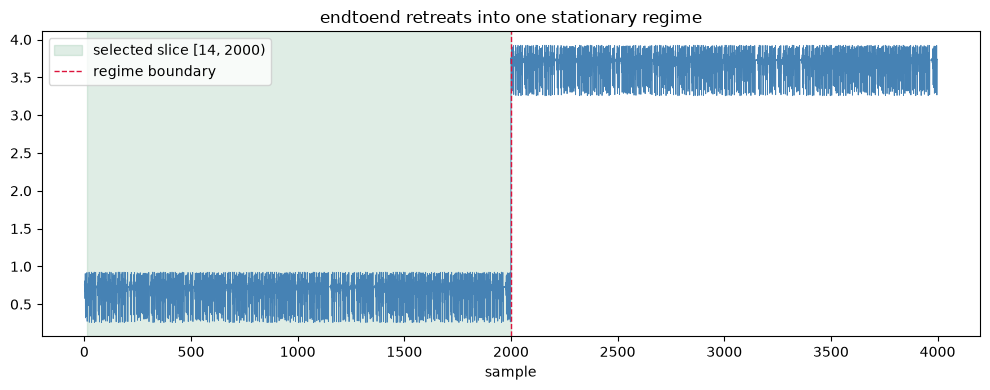

In [3]:
two_regime = np.concatenate([lg, lg + 3.0])
res2 = endtoend(two_regime)
print(f"two-regime: length = {res2['length']}, offset = {res2['offset']}, "
      f"weighted = {res2['weighted']:.2e}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(two_regime, lw=0.6, color="steelblue")
xa = res2["offset"]
xb = res2["offset"] + res2["length"]
ax.axvspan(xa, xb, color="seagreen", alpha=0.15,
           label=f"selected slice [{xa}, {xb})")
ax.axvline(2000, color="crimson", ls="--", lw=1, label="regime boundary")
ax.set_xlabel("sample")
ax.set_title("endtoend retreats into one stationary regime")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 2. `surrogates` — FT, AAFT and IAAFT surrogates

Three generators of increasing fidelity, all phase-randomising in the
frequency domain:

- **`ft`** randomises the FFT phases: the power spectrum is preserved
  *exactly*, but the amplitude distribution is destroyed.
- **`aaft`** adds a rank-ordering pre- and post-transform, so the
  distribution is preserved *exactly* while the spectrum is preserved only
  crudely.
- **`iaaft`** iterates spectrum- and distribution-matching steps until the
  spectrum converges; both properties hold to high accuracy.  It returns
  the surrogate together with the iteration count and the final
  normalised spectral RMSD.

In [4]:
np.random.seed(12345)
s_ft = ft(lg_slice)
s_aaft = aaft(lg_slice)
s_iaaft, n_iter, err = iaaft(lg_slice)

amp = np.abs(np.fft.rfft(lg_slice))
print(f"iaaft: {n_iter} iterations, normalised spectral RMSD = {err:.2e}")
print()
print("max relative spectrum deviation / distribution preserved:")
for name, s in (("ft   ", s_ft), ("aaft ", s_aaft), ("iaaft", s_iaaft)):
    dev = np.max(np.abs(np.abs(np.fft.rfft(s)) - amp) / amp)
    keep = np.array_equal(np.sort(s), np.sort(lg_slice))
    print(f"  {name}: {dev:9.2e}   {keep}")

iaaft: 281 iterations, normalised spectral RMSD = 1.04e-03

max relative spectrum deviation / distribution preserved:
  ft   :  6.44e-14   False
  aaft :  6.03e+01   True
  iaaft:  6.67e-01   True


The trade-offs are visible at a glance: FT keeps the spectrum but not the
histogram, AAFT keeps the histogram but not the spectrum, IAAFT keeps both.

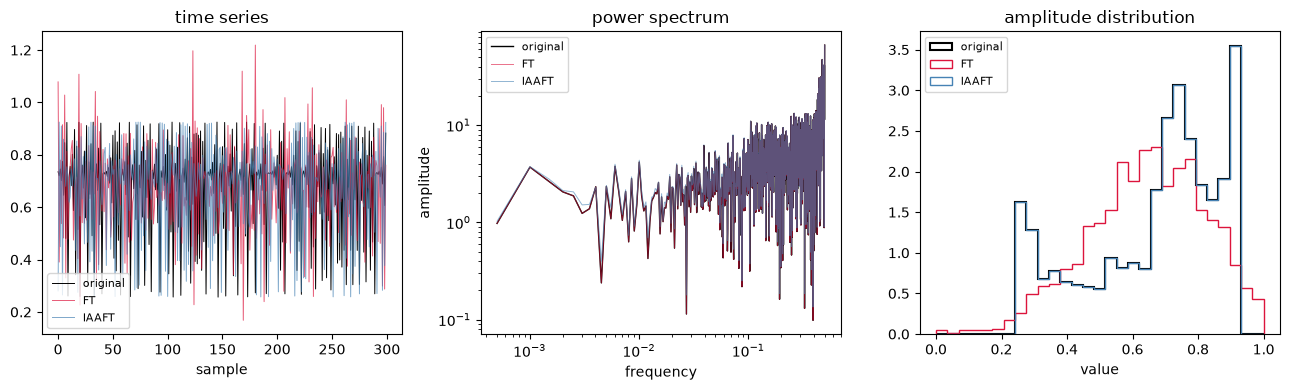

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(lg_slice[:300], lw=0.7, color="k", label="original")
axes[0].plot(s_ft[:300], lw=0.7, color="crimson", alpha=0.7, label="FT")
axes[0].plot(s_iaaft[:300], lw=0.7, color="steelblue", alpha=0.7,
             label="IAAFT")
axes[0].set_xlabel("sample")
axes[0].set_title("time series")
axes[0].legend(loc="lower left", fontsize=8)

freqs = np.linspace(0, 0.5, amp.size)
axes[1].loglog(freqs[1:], amp[1:], color="k", lw=1, label="original")
axes[1].loglog(freqs[1:], np.abs(np.fft.rfft(s_ft))[1:], lw=0.7,
               color="crimson", alpha=0.6, label="FT")
axes[1].loglog(freqs[1:], np.abs(np.fft.rfft(s_iaaft))[1:], lw=0.7,
               color="steelblue", alpha=0.6, label="IAAFT")
axes[1].set_xlabel("frequency")
axes[1].set_ylabel("amplitude")
axes[1].set_title("power spectrum")
axes[1].legend(fontsize=8)

bins = np.linspace(0, 1, 30)
axes[2].hist(lg_slice, bins=bins, histtype="step", color="k", lw=1.5,
             density=True, label="original")
axes[2].hist(s_ft, bins=bins, histtype="step", color="crimson",
             density=True, label="FT")
axes[2].hist(s_iaaft, bins=bins, histtype="step", color="steelblue",
             density=True, label="IAAFT")
axes[2].set_xlabel("value")
axes[2].set_title("amplitude distribution")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. `statistics.time_reversibility` — a nonlinear discriminant

The time-reversal asymmetry of a scalar series with delay 1 is

    T = sum (x[n] - x[n-1])**3 / sum (x[n] - x[n-1])**2 .

It vanishes in expectation for time-reversible processes — in particular
for *any* Gaussian linear process — but is typically non-zero for chaotic
maps, whose trajectories rise fast and fall slowly (or vice versa).

**Ensemble test.**  Generate 39 IAAFT surrogates of the data (same spectrum
and distribution, linearised dynamics), compute T on the data and on every
surrogate, and rank the data value within the surrogate pool.  The
one-sided p-value is `(#surrogates at least as extreme + 1) / 40`; the
smallest reachable value with 39 surrogates is 0.025.  For linear data the
data value must instead fall *inside* the surrogate range (a two-sided
check).

In [6]:
np.random.seed(2024)
surr_lg = [iaaft(lg_slice)[0] for _ in range(39)]
surr_ar = [iaaft(ar)[0] for _ in range(39)]

T_lg = time_reversibility(lg_slice)
T_lg_s = np.array([time_reversibility(s) for s in surr_lg])
p_lg = (np.sum(np.abs(T_lg_s) >= abs(T_lg)) + 1) / 40

T_ar = time_reversibility(ar)
T_ar_s = np.array([time_reversibility(s) for s in surr_ar])
p_ar = (np.sum(np.abs(T_ar_s) >= abs(T_ar)) + 1) / 40

print("time reversibility (reject if p <= 0.05):")
print(f"  logistic: T = {T_lg:+.4f}, surrogates "
      f"{T_lg_s.mean():+.4f} +- {T_lg_s.std():.4f}, p = {p_lg:.3f}  -> "
      f"{'REJECT null (nonlinear)' if p_lg <= 0.05 else 'retain null'}")
print(f"  AR(1)   : T = {T_ar:+.4f}, surrogates "
      f"{T_ar_s.mean():+.4f} +- {T_ar_s.std():.4f}, p = {p_ar:.3f}  -> "
      f"{'REJECT null (nonlinear)' if p_ar <= 0.05 else 'retain null (linear ok)'}")

time reversibility (reject if p <= 0.05):
  logistic: T = -0.1022, surrogates +0.0003 +- 0.0013, p = 0.025  -> REJECT null (nonlinear)
  AR(1)   : T = -0.0753, surrogates +0.0057 +- 0.0661, p = 0.225  -> retain null (linear ok)


The chaotic map sits far outside its surrogate ensemble (large negative
asymmetry), while the AR(1) process lands comfortably inside — exactly the
pattern a valid surrogate test must produce.

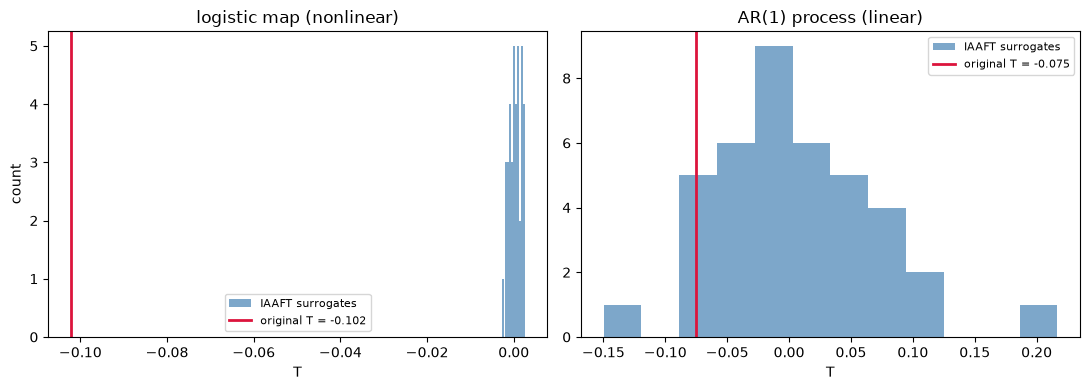

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, T0, Ts, title in (
    (axes[0], T_lg, T_lg_s, "logistic map (nonlinear)"),
    (axes[1], T_ar, T_ar_s, "AR(1) process (linear)"),
):
    ax.hist(Ts, bins=12, color="steelblue", alpha=0.7,
            label="IAAFT surrogates")
    ax.axvline(T0, color="crimson", lw=2,
               label=f"original T = {T0:+.3f}")
    ax.set_xlabel("T")
    ax.set_title(title)
    ax.legend(fontsize=8)

axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

## 4. `statistics.predict_stat` — prediction-error discriminant

The second discriminator is the root-mean-square error of a locally
constant (zeroth-order) forecast: delay-embed the series, predict each
point as the mean of its neighbours' futures.  For a *deterministic* system
nearby trajectories have nearby futures, so the error is small;
phase-randomised surrogates destroy exactly this neighbourhood structure
while keeping the spectrum, so their prediction error is much larger.
For linear data the original and its surrogates are statistically
indistinguishable — the data value may sit anywhere inside the ensemble.

`predict_stat(series, dim, delay, frac=...)` sets the neighbourhood radius
as a fraction of the series standard deviation.

In [8]:
P_lg = predict_stat(lg_slice, dim=3, delay=1, frac=0.1)
P_lg_s = np.array([predict_stat(s, dim=3, delay=1, frac=0.1)
                   for s in surr_lg])
p_lg_p = (np.sum(P_lg_s <= P_lg) + 1) / 40   # lower error = more extreme

P_ar = predict_stat(ar, dim=3, delay=1, frac=0.1)
P_ar_s = np.array([predict_stat(s, dim=3, delay=1, frac=0.1)
                   for s in surr_ar])
p_ar_p = (np.sum(P_ar_s <= P_ar) + 1) / 40

print("prediction error (reject if p <= 0.05):")
print(f"  logistic: err = {P_lg:.4f}, surrogates "
      f"{P_lg_s.mean():.4f} +- {P_lg_s.std():.4f}, p = {p_lg_p:.3f}  -> "
      f"{'REJECT null (nonlinear)' if p_lg_p <= 0.05 else 'retain null'}")
print(f"  AR(1)   : err = {P_ar:.4f}, surrogates "
      f"{P_ar_s.mean():.4f} +- {P_ar_s.std():.4f}, p = {p_ar_p:.3f}  -> "
      f"{'REJECT null (nonlinear)' if p_ar_p <= 0.05 else 'retain null (linear ok)'}")

prediction error (reject if p <= 0.05):
  logistic: err = 0.0039, surrogates 0.1568 +- 0.0027, p = 0.025  -> REJECT null (nonlinear)
  AR(1)   : err = 1.9047, surrogates 1.9003 +- 0.0292, p = 0.550  -> retain null (linear ok)


For the logistic map the original error sits more than an order of
magnitude below the surrogate ensemble — deterministic structure that no
linear process can reproduce.  For the AR(1) process the original lies
inside the surrogate cloud, so the null hypothesis of a linear origin is
retained.

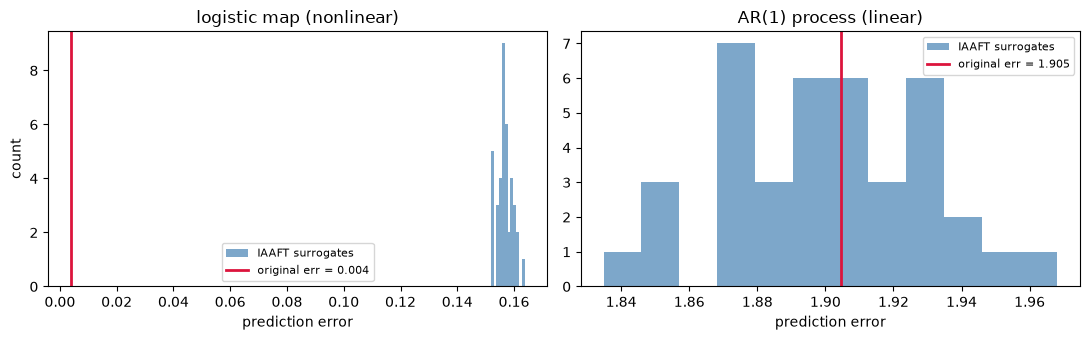

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, P0, Ps, title in (
    (axes[0], P_lg, P_lg_s, "logistic map (nonlinear)"),
    (axes[1], P_ar, P_ar_s, "AR(1) process (linear)"),
):
    ax.hist(Ps, bins=12, color="steelblue", alpha=0.7,
            label="IAAFT surrogates")
    ax.axvline(P0, color="crimson", lw=2,
               label=f"original err = {P0:.3f}")
    ax.set_xlabel("prediction error")
    ax.set_title(title)
    ax.legend(fontsize=8)

axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

## Summary

The complete surrogate-testing workflow of `nolitisea.surrogates`:

| Step | Routine | Role |
|------|---------|------|
| 1 | `endtoend.endtoend` | trim the series to the slice with the smoothest wrap-around (protects the FFT-based surrogates) |
| 2 | `surrogates.iaaft` | build the null ensemble: same spectrum and distribution, linearised dynamics |
| 3 | `statistics.time_reversibility`, `statistics.predict_stat` | discriminating statistics computed on data and ensemble |
| 4 | rank test | data value extreme -> nonlinear; inside the ensemble -> linear description suffices |

Applied to the two running examples, both statistics reject the linear null
for the chaotic logistic map (p = 1/40, the smallest value reachable with 39
surrogates) and retain it for the Gaussian AR(1) process (comfortably
mid-range ranks).  The same protocol extends to any scalar statistic — the
surrogate ensemble supplies the null distribution, the statistic supplies
the question.